#📌 Extracción

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Biblioteca para gráficos estadísticos atractivos

# Descargar datos y convertir a DataFrame
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
data_json = requests.get(url).json()
df = pd.DataFrame(data_json)

# Mostramos solo un encabezado limpio para confirmar que cargó
df.head(3)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [3]:
# 🔧 Celda 2: Transformación (Desanidar columnas)
# json_normalize extrae los diccionarios y los convierte en columnas
df_customer = pd.json_normalize(df['customer']).add_prefix('customer_')
df_phone = pd.json_normalize(df['phone']).add_prefix('phone_')
df_internet = pd.json_normalize(df['internet']).add_prefix('internet_')
df_account = pd.json_normalize(df['account']).add_prefix('account_')

# Unimos todo al DataFrame original y nos quedamos con una tabla plana
df_clean = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# Aseguramos que los cargos totales sean valores numéricos
df_clean['account_Charges.Total'] = pd.to_numeric(df_clean['account_Charges.Total'], errors='coerce').fillna(0)

#📊 Carga y análisis

In [5]:
# Seleccionamos Antigüedad (tenure), Cargo Mensual y Gasto Total
columnas_numericas = ['customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']

# Usamos describe() para obtener las métricas estadísticas clave
estadisticas = df_clean[columnas_numericas].describe()

print("--- Estadísticas Descriptivas ---")
display(estadisticas)

--- Estadísticas Descriptivas ---


,customer_tenure,account_Charges.Monthly,account_Charges.Total
count,7267.000000,7267.000000,7267.000000
mean,32.346498,64.720098,2277.182035
std,24.571773,30.129572,2268.648587
min,0.000000,18.250000,0.000000
25%,9.000000,35.425000,396.200000
50%,29.000000,70.300000,1389.200000
75%,55.000000,89.875000,3778.525000
max,72.000000,118.750000,8684.800000


/tmp/ipykernel_165/2112808600.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Churn', palette=['#2ECC71', '#E74C3C'])
/tmp/ipykernel_165/2112808600.py:6: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df_clean, x='Churn', palette=['#2ECC71', '#E74C3C'])


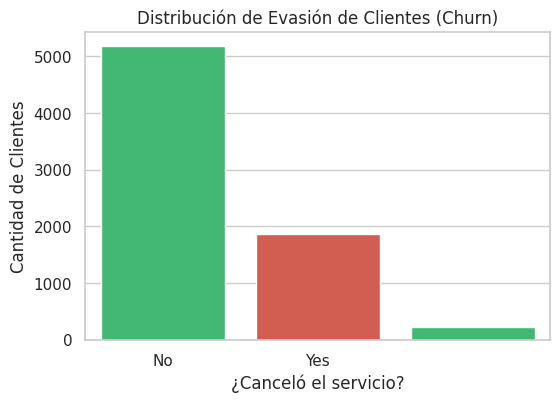

Tasa de retención: 71.2%
Tasa de evasión (Churn): 25.7%


In [9]:
# 📊 2. Distribución de Evasión
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='Churn', palette=['#2ECC71', '#E74C3C'])
plt.title('Distribución de Evasión de Clientes (Churn)')
plt.ylabel('Cantidad de Clientes')
plt.xlabel('¿Canceló el servicio?')
plt.show()

# Pequeño cálculo para ver el porcentaje exacto
porcentaje_churn = df_clean['Churn'].value_counts(normalize=True) * 100
print(f"Tasa de retención: {porcentaje_churn['No']:.1f}%")
print(f"Tasa de evasión (Churn): {porcentaje_churn['Yes']:.1f}%")

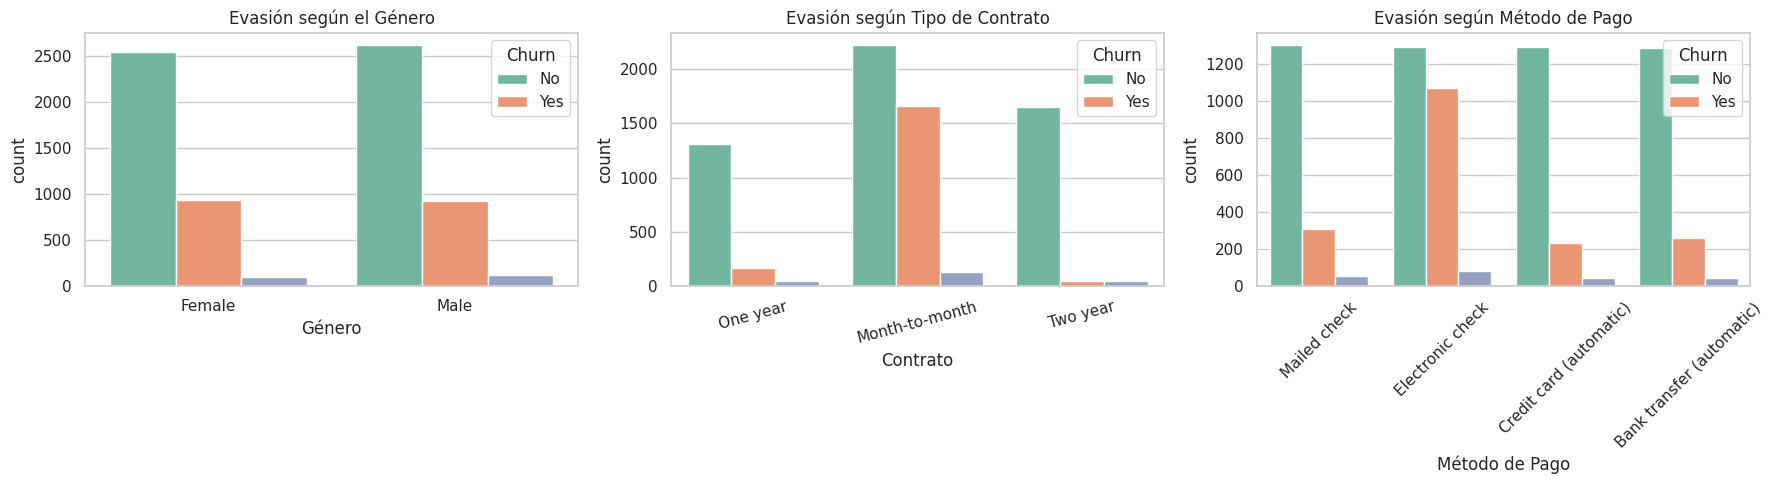

In [7]:
# 📊 3. Evasión por Variables Categóricas
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico A: Por Género
sns.countplot(data=df_clean, x='customer_gender', hue='Churn', palette='Set2', ax=axes[0])
axes[0].set_title('Evasión según el Género')
axes[0].set_xlabel('Género')

# Gráfico B: Por Tipo de Contrato
sns.countplot(data=df_clean, x='account_Contract', hue='Churn', palette='Set2', ax=axes[1])
axes[1].set_title('Evasión según Tipo de Contrato')
axes[1].set_xlabel('Contrato')
axes[1].tick_params(axis='x', rotation=15) # Inclinamos el texto para que se lea mejor

# Gráfico C: Por Método de Pago
sns.countplot(data=df_clean, x='account_PaymentMethod', hue='Churn', palette='Set2', ax=axes[2])
axes[2].set_title('Evasión según Método de Pago')
axes[2].set_xlabel('Método de Pago')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_165/1937723161.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn', y='customer_tenure', palette=['#2ECC71', '#E74C3C'], ax=axes[0])
/tmp/ipykernel_165/1937723161.py:5: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df_clean, x='Churn', y='customer_tenure', palette=['#2ECC71', '#E74C3C'], ax=axes[0])
/tmp/ipykernel_165/1937723161.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn', y='account_Charges.Total', palette=['#2ECC71', '#E74C3C'], ax=axes[1])
/tmp/ipykernel_165/1937723161.py:10: UserWarning: 
The palette list has fewer

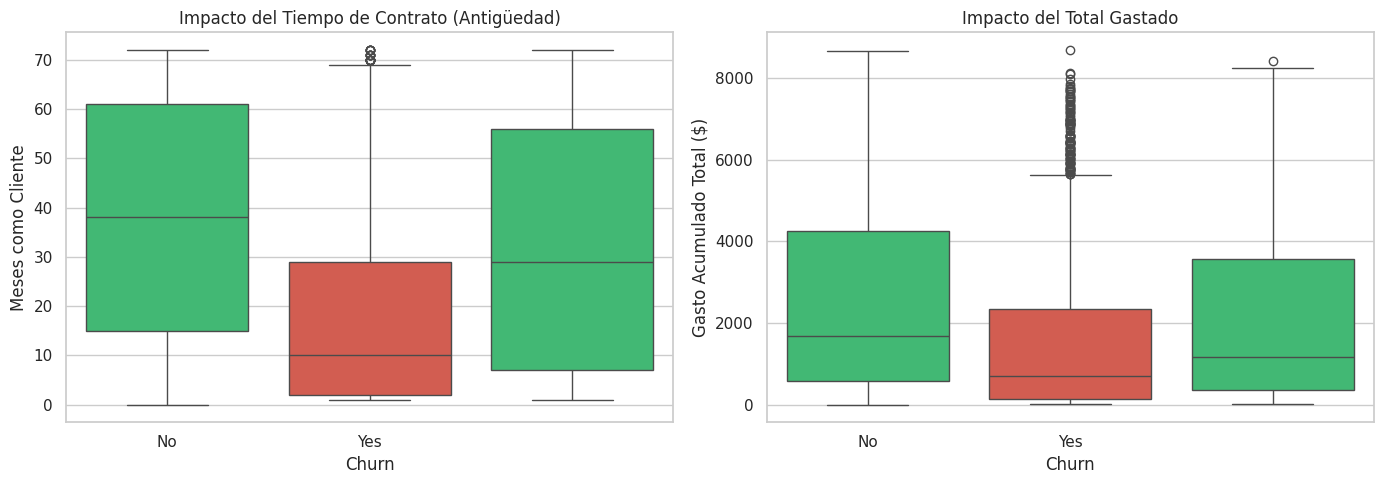

In [10]:
# 📊 4. Evasión por Variables Numéricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Antigüedad vs Churn
sns.boxplot(data=df_clean, x='Churn', y='customer_tenure', palette=['#2ECC71', '#E74C3C'], ax=axes[0])
axes[0].set_title('Impacto del Tiempo de Contrato (Antigüedad)')
axes[0].set_ylabel('Meses como Cliente')

# Gráfico B: Gasto Total vs Churn
sns.boxplot(data=df_clean, x='Churn', y='account_Charges.Total', palette=['#2ECC71', '#E74C3C'], ax=axes[1])
axes[1].set_title('Impacto del Total Gastado')
axes[1].set_ylabel('Gasto Acumulado Total ($)')

plt.tight_layout()
plt.show()

#📄Informe final

## Conclusiones y Estrategias para Incrementar la Retención
1. **El género no es un factor de riesgo**:
Hombres y mujeres cancelan el servicio exactamente en la misma proporción.

**Acción recomendada:** El equipo de marketing no debe invertir recursos en crear campañas de retención segmentadas por género, ya que no tendrán un impacto real en la reducción del Churn.

2. **El problema radica en la falta de compromiso a largo plazo:**
La inmensa mayoría de las cancelaciones provienen de usuarios con contratos de "Mes a mes". Por el contrario, los clientes que firman contratos de 1 o 2 años muestran una tasa de fidelidad altísima y rara vez abandonan la empresa.

💡 ***Estrategias de Retención (Insights Accionables):***

Para reducir la evasión, el objetivo principal de Telecom X debe ser migrar a los clientes de la modalidad mensual a contratos anuales. Se recomiendan las siguientes tácticas:

Incentivos de Migración (Upselling): Ofrecer beneficios atractivos a los clientes mensuales actuales para que firmen por un año. Por ejemplo: "Firma por 1 año y obtén el primer mes gratis" o "Actualiza a contrato anual y recibe un aumento en la velocidad de tu internet sin costo adicional".

Penalización vs. Recompensa en los precios: Estructurar los precios de tal forma que el contrato "Mes a mes" sea visiblemente más costoso a largo plazo, haciendo que el contrato de 1 o 2 años se perciba como una "oferta inteligente" (ahorro mensual) desde el primer día.

Intervención Temprana (Onboarding): Dado que los clientes mensuales se van rápido, implementar un programa de seguimiento al cliente durante sus primeros 3 meses. Asegurar que no tengan problemas técnicos en esa etapa temprana aumentará su confianza para atarse a un contrato a largo plazo.